In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import adjusted_rand_score as _ARI
import pickle

In [52]:
# --------------------------------------------------------------------------------------
# Best and worst performing stocks
# --------------------------------------------------------------------------------------

value_sel = "cagr_rel_cusum"  # "cagr_rel_ex_ante"

results_csv = "/Users/chrismader/Python/SLDS/DRO/gridsearch_results.csv"
res = pd.read_csv(results_csv)

# subset = res[
#     (res["config"] == "[g,v]") &
#     (res["n_regimes"] == 4) &
#     (res["dim_latent"] == 2)]

subset = res[
    (res["config"] == "[y]") &
    (res["n_regimes"] == 6) &
    (res["dim_latent"] == 1)]

# Exclude +/- inf and NaN
subset = (subset
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[value_sel])
)

# Highest performing stock
best_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmax()])
best_security = best_row["security"]
print('Best ', best_security, round(best_row[value_sel],3))

# Worst performing stock
worst_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmin()])
worst_security = worst_row["security"]
print('Worst', worst_security, round(worst_row[value_sel],3))


Best  META 0.076
Worst NVDA -0.088


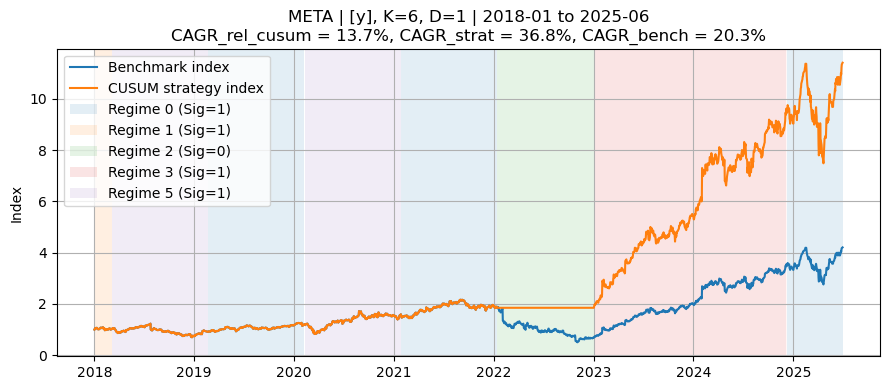

In [3]:
# --------------------------------------------------------------------------------------
# Plot Eval Charts (CUSUM, exact reproduction of cagr_rel_cusum, with optional date range)
# --------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

from gridsearch import import_data, compute_score


def _parse_dt(dt_val):
    # dt stored as "1/252" or numeric
    if isinstance(dt_val, str):
        dt_val = dt_val.strip()
        if "/" in dt_val:
            return float(Fraction(dt_val))
        return float(dt_val)
    return float(dt_val)


def _infer_regime_signals_from_index(px, z, strat_index):
    """
    Infer regime -> {0,1} mapping used inside compute_score from the realized
    strategy index and benchmark returns.
    """
    bench_ret = px.pct_change().fillna(0)
    z = np.asarray(z)
    sig_map = {}

    for r in np.unique(z):
        idx_r = np.where(z == r)[0]
        ws = []
        for t in idx_r:
            if t == 0:
                continue
            br = float(bench_ret.iloc[t])
            if br == 0.0:
                continue
            si_prev = float(strat_index.iloc[t - 1])
            si_curr = float(strat_index.iloc[t])
            if si_prev <= 0:
                continue
            g = si_curr / si_prev - 1.0
            w = g / br
            if np.isfinite(w):
                ws.append(w)

        if not ws:
            sig = 0
        else:
            m = np.median(ws)
            sig = 1 if m > 0.5 else 0
        sig_map[r] = sig

    return sig_map


def plot_cagr_from_files(
    results_csv,
    segments_parquet,
    data_excel,
    security,
    config,
    n_regimes,
    dim_latent,
    start_date=None,     
    end_date=None,          
    atol=1e-12,
    rtol=1e-12,
):

    # ---------- 1. Load results and locate row ----------
    res = pd.read_csv(results_csv)

    row = res[
        (res["security"] == security)
        & (res["config"] == config)
        & (res["n_regimes"] == n_regimes)
        & (res["dim_latent"].astype(str) == str(dim_latent))
    ]

    if len(row) != 1:
        raise ValueError(f"Expected exactly one matching row, got {len(row)}")

    row = row.iloc[0]

    if "cagr_rel_cusum" not in row or pd.isna(row["cagr_rel_cusum"]):
        raise ValueError("cagr_rel_cusum missing in results CSV for this row.")

    cagr_rel_cusum_stored = float(row["cagr_rel_cusum"])
    dt = _parse_dt(row["dt"])

    # ---------- 2. Load parquet and extract CUSUM regimes ----------
    seg = pd.read_parquet(segments_parquet)

    seg = seg[
        (seg["security"] == security)
        & (seg["config"] == config)
        & (seg["n_regimes"] == n_regimes)
        & (seg["dim_latent"].astype(str) == str(dim_latent))
    ]

    if seg.empty:
        raise ValueError("No matching rows found in segments parquet for this model selection.")

    seg = seg.sort_values("date")
    z = seg["z"].to_numpy()
    dates = pd.to_datetime(seg["date"].to_numpy())

    # ---------- 3. Load prices and align ----------
    px_all, _, _, _ = import_data(data_excel)

    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")

    px_full = px_all[security].dropna()

    # Align by date intersection with segment dates
    idx = px_full.index.intersection(dates)
    if len(idx) == 0:
        raise ValueError("No overlapping dates between prices and segments.")

    idx = idx.sort_values()
    px = px_full.loc[idx]

    # Map z onto this index
    seg_aligned = seg.set_index(pd.to_datetime(seg["date"])).loc[idx]
    z_aligned = seg_aligned["z"].to_numpy()

    if len(z_aligned) != len(px):
        raise ValueError(
            f"Length mismatch after alignment: len(px)={len(px)}, len(z)={len(z_aligned)}"
        )

    # ---------- 4. Optional date filter on the aligned series ----------
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]

        mask = (px.index >= start) & (px.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range.")

        px = px.loc[mask]
        z_aligned = z_aligned[mask] 

    # ---------- 5. Recompute performance using ORIGINAL compute_score ----------
    cagr_rel, cagr_strat, cagr_bench, strat_index, bench_index, _ = compute_score(
        px, z_aligned, dt
    )

    # Only enforce equality with stored cagr_rel_cusum if using full history
    if start_date is None and end_date is None:
        if not np.isclose(cagr_rel, cagr_rel_cusum_stored, rtol=rtol, atol=atol):
            raise ValueError(
                f"Recomputed cagr_rel_cusum={cagr_rel:.10f} "
                f"!= stored {cagr_rel_cusum_stored:.10f}"
            )

    # ---------- 6. Infer regime -> signal mapping ----------
    sig_map = _infer_regime_signals_from_index(px, z_aligned, strat_index)

    # ---------- 7. Plot ----------
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))

    ax.plot(px.index, bench_index, label="Benchmark index")
    ax.plot(px.index, strat_index, label="CUSUM strategy index")

    ymin, ymax = ax.get_ylim()
    used_labels = set()
    for regime in np.unique(z_aligned):
        mask_reg = (z_aligned == regime)
        sig = sig_map.get(regime, 0)
        lbl = f"Regime {regime} (Sig={sig})"
        label = lbl if lbl not in used_labels else None
        used_labels.add(lbl)
    
        ax.fill_between(
            px.index,
            ymin,
            ymax,
            where=mask_reg,
            alpha=0.12,
            step="pre",
            label=label,
        )
    
    ax.set_ylim(ymin, ymax)

    # title
    title = (
        f"{security} | {config} | K={n_regimes}, D={dim_latent}\n"
        f"CAGR_rel_cusum = {cagr_rel:.4%}, "
        f"CAGR_strat = {cagr_strat:.4%}, "
        f"CAGR_bench = {cagr_bench:.4%}"
    )
    if start_date is not None or end_date is not None:
        title = (
            f"{security} | {config}, K={n_regimes}, D={dim_latent} "
            f"| {px.index[0].strftime('%Y-%m')} to {px.index[-1].strftime('%Y-%m')}\n"
            f"CAGR Rel = {cagr_rel * 100:.1f}%, "
            f"CAGR Strat = {cagr_strat * 100:.1f}%, "
            f"CAGR Bench = {cagr_bench * 100:.1f}%"
        )

    ax.set_title(title)
    ax.set_ylabel("Index")
    ax.legend(loc="best")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "cagr_rel_cusum": cagr_rel,
        "cagr_strat": cagr_strat,
        "cagr_bench": cagr_bench,
        "regime_signal_map": sig_map,
    }

    
data_excel = "/Users/chrismader/Python/SLDS/Data/bbg_data.xlsx"
results_csv = "/Users/chrismader/Python/SLDS/DRO/gridsearch_results.csv"
segments_parquet = "/Users/chrismader/Python/SLDS/DRO/gridsearch_segments.parquet"
security = "META"

_ = plot_cagr_from_files(
    results_csv=results_csv,
    segments_parquet=segments_parquet,
    data_excel=data_excel,
    security=security,
    # config="[g,v]",
    config="[y]",
    n_regimes=6,
    dim_latent=1,
    start_date="2018",
    end_date=None,
)